In [ ]:
# Import Library
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset

In [7]:
# Load Dataset
df = pd.read_csv('../data/house_prices_dataset.csv')

# Preview Dataset
df.sample(10).T

,347,354,1200,205,1410,645,743,1054,910,171
Id,348,355,1201,206,1411,646,744,1055,911,172
MSSubClass,20,50,20,20,60,20,80,60,90,20
MSZoning,RL,RL,RL,RL,RL,RL,RL,RL,RL,RL
LotFrontage,NaN,60.0,71.0,99.0,79.0,NaN,70.0,90.0,80.0,141.0
LotArea,17600,8400,9353,11851,12420,10530,12886,11367,11600,31770
...,...,...,...,...,...,...,...,...,...,...
MoSold,12,6,7,5,6,3,10,11,1,5
YrSold,2009,2006,2006,2009,2009,2007,2009,2006,2010,2010
SaleType,WD,WD,Oth,WD,WD,WD,WD,WD,WD,WD
SaleCondition,Normal,Normal,Abnorml,Normal,Normal,Normal,Normal,Normal,Normal,Normal


In [8]:
# Identifikasi Karakteristik Dataset
print(f"Jumlah Baris : {df.shape[0]}")
print(f"Jumlah Kolom : {df.shape[1]}")
print(f"Total Duplikat: {df.duplicated().sum()}")

Jumlah Baris : 1460
Jumlah Kolom : 81
Total Duplikat: 0


# Exploratory Data Analysis

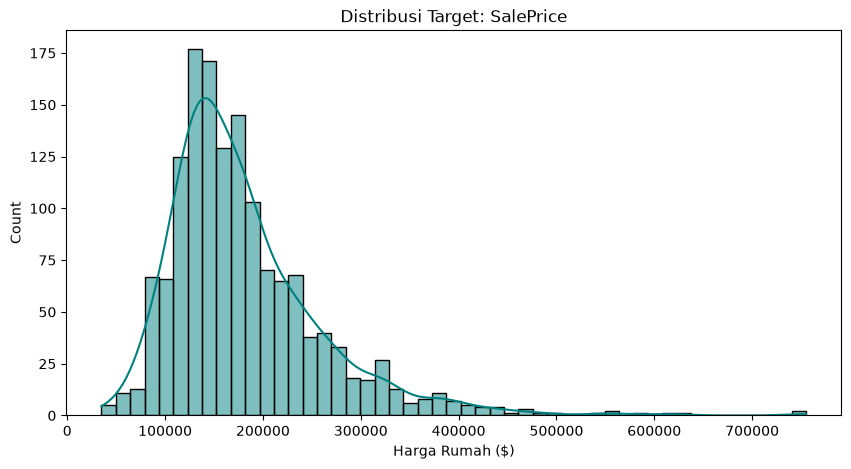

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [12]:
# Identifikasi Distribusi Variabel "SalePrice" (Target)
plt.figure(figsize=(10, 5))
sns.histplot(df["SalePrice"], kde=True, color="teal")
plt.title("Distribusi Target: SalePrice")
plt.xlabel("Harga Rumah ($)")
plt.show()

print(df["SalePrice"].describe())

**Insight:**

Berdasarkan visualisasi distribusi variabel `SalePrice` yang menjadi Target dalam prediksi harga rumah ini menunjukkan bahwa distribusi tersebut merupakan distribusi right skewed dengan nilai mean sebesar 180,921 dolar lebih tinggi dibandingkan nilai median sebesar 163,000 dolar karena terpengaruh oleh sejumlah kecil rumah berharga tinggi hingga 755,000 dolar. Oleh karena itu, mayoritas transaksi berpusat pada rumah kelas menengah hingga bawah.

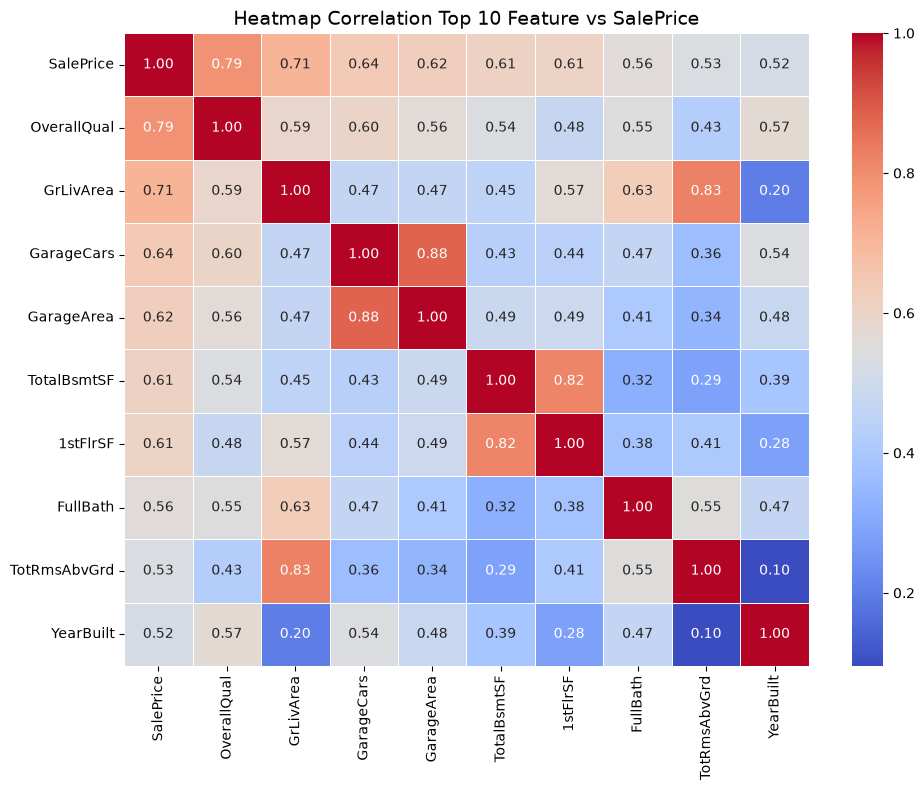

In [13]:
# Identifikasi Top 10 Feature yang Paling Berkorelasi Dengan "SalePrice"
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
top_corr_features = corr["SalePrice"].sort_values(ascending=False).head(10).index

plt.figure(figsize=(10, 8))
sns.heatmap(
    numeric_df[top_corr_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
)
plt.title("Heatmap Correlation Top 10 Feature vs SalePrice", fontsize=14)
plt.tight_layout()
plt.show()

**Insight:**

Berdasarkan visualisasi heatmap correlation top 10 feature yang paling berkorelasi dengan target menunjukkan bahwa harga rumah (`SalePrice`) paling dipengaruhi oleh `OverallQual`, `GrLivArea`, `GarageCars`, dan `TotalBsmtSF`. Selain itu terdapat multikolinearitas yang kuat, seperti antara `GarageCars` dan `GarageArea`, `TotalBsmtSF` dan `1stFlrSF`, serta `GrLivArea` dan `TotRmsAbvGrd`.

# Split Dataset

In [15]:
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test : {X_test.shape}")

Ukuran X_train: (1168, 80)
Ukuran X_test : (292, 80)


# Data Preprocessing

In [16]:
# Menentukan Kolom Numerik dan Kategorikal Pada Data Train
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

# Pipeline Preprocessing Numerik (Median Imputation + Scaling)
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline Preprocessing Kategorikal (Mode Imputation + One-Hot Encoding)
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Menggabungkan Preprocessor
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# Fit & Transform pada data train, Transform pada data test
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(f"Bentuk data setelah preprocessing: {X_train_prep.shape}")

Bentuk data setelah preprocessing: (1168, 286)


# Model Training & Evaluation

In [20]:
# Menentukan Model Machine Learning
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10.0),
    "Lasso Regression": Lasso(alpha=1.0, max_iter=10000, random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
}

# Melakukan Model Training & Langsung Menyimpan Hasil Prediksi
trained_models = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_prep, y_train)
    trained_models[name] = model

    predictions[name] = model.predict(X_test_prep)
    print(f"Model {name} telah selesai dilatih dan diprediksi.")

Model Linear Regression telah selesai dilatih dan diprediksi.
Model Ridge Regression telah selesai dilatih dan diprediksi.
Model Lasso Regression telah selesai dilatih dan diprediksi.
Model Random Forest telah selesai dilatih dan diprediksi.



=== Evaluasi Detail Setiap Model ===
            Model    MAE ($)   RMSE ($) R2 Score
Linear Regression $18,284.90 $29,477.00   0.8867
 Ridge Regression $19,018.33 $30,652.70   0.8775
 Lasso Regression $17,917.29 $28,238.39   0.8960
    Random Forest $17,546.71 $28,527.52   0.8939


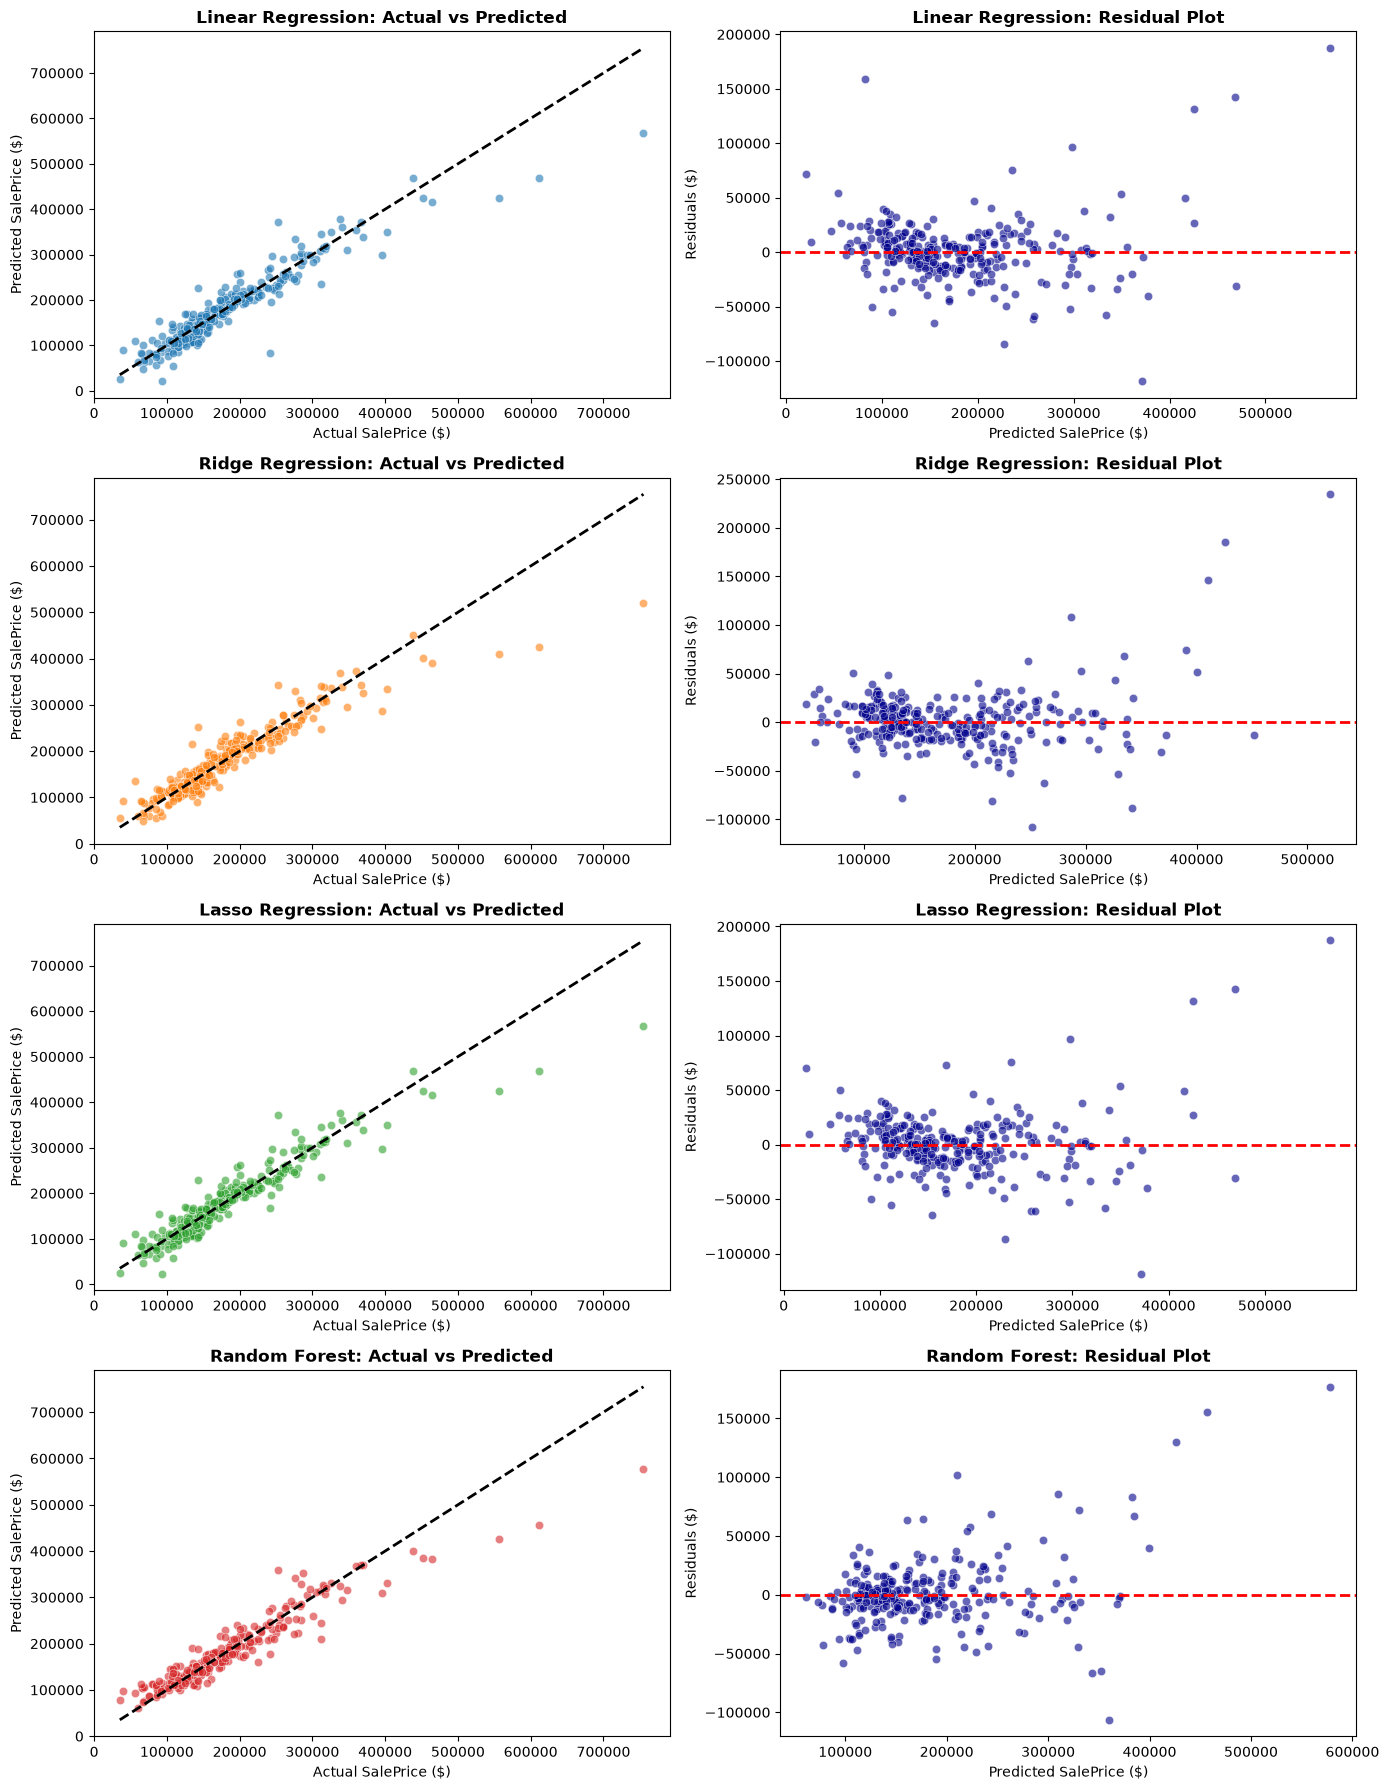

In [21]:
# Evaluasi Detail Setiap Model & Simpan ke DataFrame
print("\n=== Evaluasi Detail Setiap Model ===")
eval_list = []

for name, preds in predictions.items():
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    eval_list.append(
        {"Model": name, "MAE ($)": mae, "RMSE ($)": rmse, "R2 Score": r2}
    )

# Tampilkan Ringkasan Sebagai Tabel Pandas
df_eval = pd.DataFrame(eval_list)
print(
    df_eval.to_string(
        index=False,
        formatters={
            "MAE ($)": "${:,.2f}".format,
            "RMSE ($)": "${:,.2f}".format,
            "R2 Score": "{:.4f}".format,
        },
    )
)

# Visualisasi Actual vs Predicted & Residual Plot
num_models = len(predictions)
fig, axes = plt.subplots(
    nrows=num_models, ncols=2, figsize=(14, 4.5 * num_models)
)
colors = sns.color_palette("tab10", n_colors=num_models)

for idx, (name, preds) in enumerate(predictions.items()):
    residuals = y_test - preds

    ax_actual = axes[idx, 0] if num_models > 1 else axes[0]
    ax_resid = axes[idx, 1] if num_models > 1 else axes[1]

    # Actual vs Predicted Plot
    sns.scatterplot(
        x=y_test, y=preds, alpha=0.6, color=colors[idx], ax=ax_actual
    )
    ax_actual.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        "k--",
        lw=2,
    )
    ax_actual.set_title(f"{name}: Actual vs Predicted", fontweight="bold")
    ax_actual.set_xlabel("Actual SalePrice ($)")
    ax_actual.set_ylabel("Predicted SalePrice ($)")

    # Residual Plot
    sns.scatterplot(
        x=preds, y=residuals, alpha=0.6, color="darkblue", ax=ax_resid
    )
    ax_resid.axhline(0, color="red", linestyle="--", lw=2)
    ax_resid.set_title(f"{name}: Residual Plot", fontweight="bold")
    ax_resid.set_xlabel("Predicted SalePrice ($)")
    ax_resid.set_ylabel("Residuals ($)")

plt.tight_layout()
plt.show()

**Insight:**

Berdasarkan hasil eksperimen awal ini menunjukkan bahwa model lasso regression dan random forest menunjukkan performa terbaik dengan masing-masing nilai nilai `R^2 Score` sebesar 0.896% dan 0.894% sehingga kedua model mampu menjelaskan sekitar 89% variansi harga rumah. Lasso regression mencatatkan tingkat kesalahan prediksi ekstrem terendah dengan RMSE sebesar 28,238 dolar yang menunjukkan lasso memiliki performa yang paling kuat, efisien secara komputasi, dan efektif mereduksi feature yang redundan akibat multikolinearitas sehingga menjadi pilihan model regresi paling optimal untuk eksperimen awal ini.